# Programming for Data Analytics Assessment

### Task 1 - Data Analytics in Python (Housing in Berlin)

In the data analysis lifecyle, there exists broadly the following stages/steps:
1. Collect data (already handled in this case as there is an existing dataset)
2. Data Preparation: which includes EDA, data transformation, and data preprocessing
3. Analysis
4. Reporting

Steps 2-4 will be conducted for this dataset

## Stage 1: Importing necessary libraries
- Pandas: data manipulation
- SciPY: statistical computations
- MatplotLib & Seaborn: plotting visualizations

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Stage 2: Initial Dataset Exploration
Dataset Overview through Exploratory Data Analysis (EDA)

In [39]:
df = pd.read_csv('BerlinHousing4049.csv')
df

,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,condition,grade,built,renovated,living_area_sqft
0,221900.0,3.0,1.00,NaN,5650.0,1.0,3.0,7,1955.0,0,1340.0
1,538000.0,3.0,NaN,2570.0,7242.0,2.0,3.0,7,1951.0,1991,1690.0
2,180000.0,2.0,1.00,NaN,10000.0,1.0,3.0,6,1933.0,0,NaN
3,604000.0,4.0,3.00,1960.0,5000.0,1.0,5.0,7,1965.0,0,1360.0
4,510000.0,3.0,2.00,1680.0,8080.0,1.0,3.0,8,1987.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
9994,1695000.0,4.0,2.75,3770.0,10900.0,2.0,5.0,9,1924.0,0,3000.0
9995,279000.0,2.0,1.00,1020.0,47044.0,1.0,5.0,7,1904.0,1958,1930.0
9996,262000.0,3.0,1.50,1700.0,9579.0,1.0,4.0,7,1962.0,0,1700.0
9997,533000.0,4.0,1.00,1550.0,4750.0,1.5,3.0,7,1919.0,0,1320.0


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             9990 non-null   float64
 1   bedrooms          9988 non-null   float64
 2   bathrooms         9990 non-null   float64
 3   sqft_living       9989 non-null   float64
 4   sqft_total        9993 non-null   float64
 5   floors            9999 non-null   float64
 6   condition         9998 non-null   float64
 7   grade             9999 non-null   int64  
 8   built             9996 non-null   float64
 9   renovated         9999 non-null   int64  
 10  living_area_sqft  9986 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 859.4 KB


In [41]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,condition,grade,built,renovated,living_area_sqft
count,9.990000e+03,9988.000000,9990.000000,9989.000000,9.993000e+03,9999.000000,9998.000000,9999.000000,9996.000000,9999.000000,9986.000000
mean,5.333292e+05,3.364638,2.063263,2052.985985,1.604135e+04,1.432043,3.446389,7.594459,1967.267307,91.642364,1975.878029
std,3.768880e+05,0.910976,0.765275,910.804284,4.505641e+04,0.511869,0.666341,1.165901,27.988813,417.830430,672.424849
min,7.500000e+04,1.000000,0.500000,380.000000,5.720000e+02,1.000000,1.000000,3.000000,1900.000000,0.000000,620.000000
25%,3.150000e+05,3.000000,1.500000,1410.000000,5.425000e+03,1.000000,3.000000,7.000000,1950.000000,0.000000,1490.000000
50%,4.458190e+05,3.000000,2.000000,1890.000000,7.916000e+03,1.000000,3.000000,7.000000,1969.000000,0.000000,1830.000000
75%,6.398000e+05,4.000000,2.500000,2500.000000,1.118000e+04,2.000000,4.000000,8.000000,1990.000000,0.000000,2340.000000
max,7.700000e+06,11.000000,8.000000,12050.000000,1.651359e+06,3.500000,5.000000,13.000000,2015.000000,2015.000000,5790.000000


In [42]:
columns_with_missing_values = len(df.columns[df.isnull().any()])
print('Columns with missing data:', columns_with_missing_values)

rows_with_missing_values = df.isnull().any(axis=1).sum()
print('Rows with missing data:', rows_with_missing_values)

missing_values = df.isnull().sum().sum()
missing_values_percentage = (missing_values / df.shape[0]) * 100
print(f'Percentage of missing values: {round(missing_values_percentage, 2)}%')

missing_values_percentage_per_column = round((df.isnull().sum() / df.shape[0]) * 100, 2)
display(missing_values_percentage_per_column.sort_values(ascending=False))

duplicates = df.duplicated().sum()
print("\nDuplicates count:", duplicates)

Columns with missing data: 8
Rows with missing data: 55
Percentage of missing values: 0.62%


living_area_sqft    0.13
bedrooms            0.11
sqft_living         0.10
price               0.09
bathrooms           0.09
sqft_total          0.06
built               0.03
condition           0.01
floors              0.00
grade               0.00
renovated           0.00
dtype: float64


Duplicates count: 2


## Stage 3: Data Preprocessing
Handling dirty data. Dirty data includes:
- Missing / empty values
- Incorrect formating
- Incorrect values / outliers
- Duplicate (redundant) data

**Case 1:** Handling duplicate data

Duplicate data is characterized by identical records within a dataset. Given that this dataset contains numerical variables only, leaving duplicates will skew the analysis among other reasons.

In [43]:
print('Row count before duplicate removal:', df.shape[0])
df.drop_duplicates(inplace=True)
print('Row count after duplicate removal:', df.shape[0])

Row count before duplicate removal: 9999
Row count after duplicate removal: 9997


**Case 2:** Handling missing data (using Listwise Deletion)

From a cell above, it is seen that the % of missing data is below 5%. This means that out of 9999 rows, there are 62 which contain missing values. Because the goal of this project is strictly for EDA rather than predictive modelling and the amount of rows with missing data compared to the overall dataset is negligible (below 5%), the rows containing the missing data will be removed as it will have little to no impact on the overall analysis.

In [44]:
print('% missing values before Listwise Deletion: 0.62%')
print('Row count before Listwise Deletion:', df.shape[0])
df.dropna(inplace=True)
print('Row count after Deduplication & Listwise Deletion:', df.shape[0])
print(f'% missing values after Listwise Deletion: {round((df.isnull().sum().sum()
/ df.shape[0]) * 100, 2)}%')

% missing values before Listwise Deletion: 0.62%
Row count before Listwise Deletion: 9997
Row count after Deduplication & Listwise Deletion: 9942
% missing values after Listwise Deletion: 0.0%


**Case 3:** Incorrect formatting

In the original dataset, several columns originally had the integer data type. Due to the presence of null values, they were converted to a float. To improve semantic correctness and interpretability, these columns will be converted to its original data type. This is also in alignment with one of the principles of Tidy Data proposed by Hadley Wickham.

Additionally, to improve readability specifically for analysis and not because the origianl names are wrong, the field names would as well be renamed.

Lastly, properties in Germany are measured in meteres squared (m2) and not sqaure feet (sqft). Related columns will be converted to the appropriate measurement unit to reflect real-world standards.

In [45]:
# 1. Changing data type
print('Data types transformation')
int_columns = [
    'price',
    'bedrooms',
    'sqft_living',
    'sqft_total',
    'condition',
    'built',
    'living_area_sqft',
]
for column in int_columns:
    df[column] = df[column].astype('int64')

display(df.dtypes)

#2. Renaming columns
print('\nColumn renaming\n')
df.rename(columns={
    'price': 'Price',
    'bedrooms': 'Number of Bedrooms',
    'bathrooms': 'Number of Bathrooms',
    'sqft_living': 'Living Area (sqft)',
    'sqft_total': 'Total Area (sqft)',
    'floors': 'Number of Floors',
    'condition': 'Property Condition',
    'grade': 'Property Grade',
    'built': 'Year Built',
    'renovated': 'Year Renovated',
    'living_area_sqft': 'Living Area (sqft) 2',
}, inplace=True)
df.columns

Data types transformation


price                 int64
bedrooms              int64
bathrooms           float64
sqft_living           int64
sqft_total            int64
floors              float64
condition             int64
grade                 int64
built                 int64
renovated             int64
living_area_sqft      int64
dtype: object


Column renaming



Index(['Price', 'Number of Bedrooms', 'Number of Bathrooms',
       'Living Area (sqft)', 'Total Area (sqft)', 'Number of Floors',
       'Property Condition', 'Property Grade', 'Year Built', 'Year Renovated',
       'Living Area (sqft) 2'],
      dtype='str')

**Case 4:** Handling Incorrect Data & Outliers

- Incorrect data is data which does accurately represent / violates the constraints of the entity involved for example house pricing being negative or total living area for a house being 0.
- Outliers on the other hand aren't necessarily incorrect data but describes observations that differ substantially from the central point of tendency of the other data points in a dataset. For example in a dataset containing net worths of wealthy individuals, majority of the data is in the millions and there's a data point or data points in the trillions.

This investigation will be split into 2 parts: handling incorrect data and then handling outliers. For the first part, notice that there are 2 columns with the same name and at first glance the same meaning `Living Area (sqft)` and `Living Area (sqft) 2`. So, this will be first handled followed by logical consistency checks to eliminate any bad (incorrect) data.

##### **1. Handling Incorrect Data:** Investigating similar columns

In [46]:
living_area_columns = df[['Living Area (sqft)', 'Living Area (sqft) 2', 'Year Renovated']].copy()
living_area_columns

,Living Area (sqft),Living Area (sqft) 2,Year Renovated
3,1960,1360,0
8,1780,1780,0
10,3560,2210,0
11,1160,1330,0
12,1430,1780,0
...,...,...,...
9994,3770,3000,0
9995,1020,1930,1958
9996,1700,1700,0
9997,1550,1320,0


In [47]:
# step 1: get the % of identical count
identical_count = (living_area_columns['Living Area (sqft)'] == living_area_columns['Living Area (sqft) 2']).sum()
differing_count = (living_area_columns['Living Area (sqft)'] != living_area_columns['Living Area (sqft) 2']).sum()

print(f'Identical count: {identical_count}')
print(f'Differing count: {differing_count}')
print(f'Percentage of Identical Count: {identical_count / len(living_area_columns) * 100:.2f}%')

Identical count: 1069
Differing count: 8873
Percentage of Identical Count: 10.75%


If one of the columns were a duplicate of the other, the identical count would have been equal (or nearly equal) to the full row count of 9942. A low percentage of 10.75 is direct evidence against duplication.

Irrespective of majority of the rows not being identical, it doesn't say anything about how far apart their unidentical values are (i.e. the difference between them). The gap will be investigated below and classified as follows:

- `gap = 0` implies identical rows which is equivalent to what was performed above.
- `gap > 0` implies `Living Area (sqft)` is bigger than `Living Area (sqft) 2` which could mean the property's living area was reduced assuming `Living Area (sqft)` is the initial size and `Living Area (sqft) 2` is the size after work was done .
- `gap < 0` implies `Living Area (sqft)` is smaller than `Living Area (sqft) 2` which could mean the property's living area was increased following the assumption above.

The size of the gap regardless of the sign will show how substantial the discrepancy is. For example, a gap of 5sqft could be noise while a gap of 2000sqft is a structurally meaningful change.



In [48]:
# step 2: distribution of the gap
living_area_columns['Gap'] = (living_area_columns['Living Area (sqft)'] - living_area_columns['Living Area (sqft) 2'])
round(living_area_columns['Gap'].describe(), 2)

count    9942.00
mean       78.24
std       602.73
min     -2310.00
25%      -240.00
50%         0.00
75%       310.00
max      8110.00
Name: Gap, dtype: float64

The `.describe()` method was used here because it summarizes the the difference (living area gap column) at once giving one gap value per row rather than 9942 values which is too many to read one by one.

Given the mean (average gap size), standard deviation (how much gap varies from row to row), and the minimimum and maximum (the most extreme cases) from above, it is seen that the gap averages ~78sqft but swings as far as -2310 and 8110 indicating that the difference is real and substantial, not just noise (meaningless variation around a value that's fundamentally the same thing) or some measuring/rounding error.

In [49]:
# step 3: testing whether gap relates to renovation status
living_area_columns['Gap Abs'] = living_area_columns['Gap'].abs()
renovated = living_area_columns[living_area_columns['Year Renovated'] > 0]
never_renovated = living_area_columns[living_area_columns['Year Renovated'] == 0]

print(f'Renovated properties -> mean absolute gap: {round(renovated["Gap Abs"].mean(), 2)}sqft (n={len(renovated)})')
print(f'Never Renovated properties -> mean absolute gap: {round(never_renovated["Gap Abs"].mean(), 2)}sqft (n={len(never_renovated)})')

print(f'Renovated % identical: {(renovated['Living Area (sqft)'] == renovated['Living Area (sqft) 2']).mean() * 100:.2f}%')
print(f'Never Renovated % identical: {(never_renovated["Living Area (sqft)"] == never_renovated["Living Area (sqft) 2"]).mean() * 100:.2f}%')

Renovated properties -> mean absolute gap: 646.73sqft (n=455)
Never Renovated properties -> mean absolute gap: 384.25sqft (n=9487)
Renovated % identical: 5.93%
Never Renovated % identical: 10.98%


**Interpretation of Results**

- The `.abs()` method was used to convert every gap to its positive size, ignoring direction so that postive and negative gaps do not canel each other out when calculating average.

- Output *646.73 (n=455)* : for the 455 properties that have been renovated, the average, the average size of discrepancy between the 2 living area columns is 646.73sqft
- Ouput *384.25 (n=9487)*: for the 9,487 properties never renovated, the average discrepancy is smaller, at 384.2 sqft. Renovated properties show a gap roughly 1.7x larger
- Output *5.93%*: of the renovated properties, only 5.93% of them have both columns matching exactly
- Output *10.98%*: never-renovated properties match almost twice as often as renovated ones

This shows that renovation status is associated with greater divergence between the two living area columns, suggesting renovation is one contributing factor to the difference. However, substantial divergence persists even among never-renovated properties, indicating the two columns likely reflect a broader distinction rather than renovation status alone. This justifies proceeding to correlation analysis as a legitimate next step for further investigation.

**2. Handling Incorrect Data:** Correlation Analysis

*For further investigation on similar columns as well as other columns in question*

To achieve this, both statistical calculation (Pearson's r) and a visualization technique (a heatmap) will be employed. Pearson's method would be used to calculate the correlation and a heatmap to visualize the resulting matrix.

Given that the dataset (fields involved) is purely numeric, Pearson's method is the best suited method to implement.

In [50]:
# 1: full pearson correlation matrix across all columns
corr = df.corr(method='pearson')
round(corr, 2)

,Price,Number of Bedrooms,Number of Bathrooms,Living Area (sqft),Total Area (sqft),Number of Floors,Property Condition,Property Grade,Year Built,Year Renovated,Living Area (sqft) 2
Price,1.00,0.30,0.52,0.70,0.09,0.28,0.04,0.65,0.04,0.14,0.58
Number of Bedrooms,0.30,1.00,0.54,0.58,0.03,0.22,0.02,0.36,0.17,0.03,0.38
Number of Bathrooms,0.52,0.54,1.00,0.77,0.09,0.50,-0.09,0.66,0.48,0.07,0.58
Living Area (sqft),0.70,0.58,0.77,1.00,0.17,0.39,-0.05,0.76,0.32,0.07,0.75
Total Area (sqft),0.09,0.03,0.09,0.17,1.00,0.02,-0.02,0.12,0.09,-0.00,0.16
Number of Floors,0.28,0.22,0.50,0.39,0.02,1.00,-0.22,0.47,0.40,0.04,0.33
Property Condition,0.04,0.02,-0.09,-0.05,-0.02,-0.22,1.00,-0.13,-0.31,-0.08,-0.09
Property Grade,0.65,0.36,0.66,0.76,0.12,0.47,-0.13,1.00,0.44,0.04,0.73
Year Built,0.04,0.17,0.48,0.32,0.09,0.40,-0.31,0.44,1.00,-0.22,0.35
Year Renovated,0.14,0.03,0.07,0.07,-0.00,0.04,-0.08,0.04,-0.22,1.00,-0.00


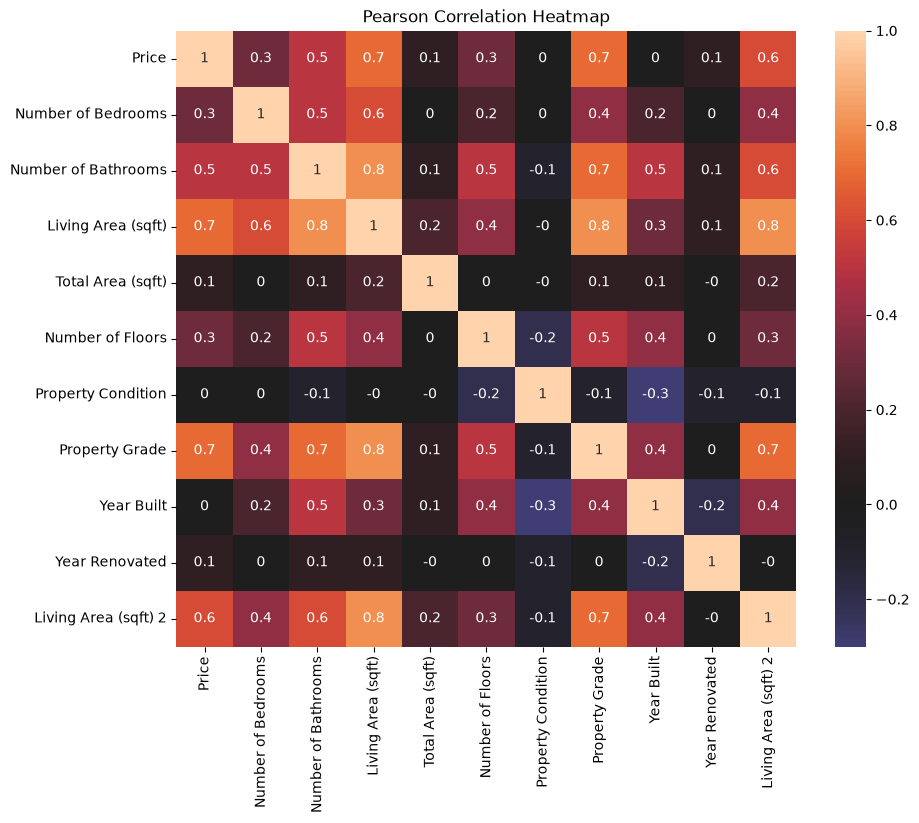

In [51]:
# displaying matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(round(corr, 1), annot=True, center=0)
plt.title('Pearson Correlation Heatmap')
plt.show()

**Interpretation of Coefficients**

A Pearson r ranges from -1 to 1 where:
- the sign tells the direction:
  - positive means both variables increase together
  - negative means one variable increases while the other decreases
- the magnitude (the actual value) tells the strength which as a rule of thumb is commonly interpreted as:
  - 0-0.3: weak
  - 0.3-0.6: moderate
  - 0.6-0.8: strong
  - 0.8-1.0: very strong

From the results above, it is seen that `Living Area (sqft)` and `Living Area (sqft) 2` have a strong positive relationship which confirms the result of the investigation above. They are highly related (r=0.8) but greatly distinct variables.

While there are other strong linear relationships such as `Property Grade vs Price`, `Living Area vs Price`, it is worth noting that this measures only linear association and does not imply causation.

**Conclusion:** `Living Area (sqft)` vs `Living Area (sqft) 2`

Only one column will be used as the working variable going forward, which will be `Living Area (sqft)` while the other one will be removed. The reasoning chain is as follows:
1. Neither column is a duplicate of the other: only 10.75% of rows match exactly implying genuinely different data.
2. Not random noise: the gap is too large (reference results of the distribution gap)
3. Partially explained by renovation: renovated properties show a bigger, more frequent gap (646.7sqft, 5.9% identical) than never renovated properties (384.2 sqft, 10.9% identical), but renovation doesn't explain it all since even properties that were never renovated still diverge substantially.
4. Strongly but incompletely correlated (r = 0.7): this confirms they are related but not interchangeable
5. `Living Area (sqft)` is the stronger relevant variable: it correlates more with the dependent variable, `Price`

In [52]:
df.drop('Living Area (sqft) 2', axis=1, inplace=True)
df.columns

Index(['Price', 'Number of Bedrooms', 'Number of Bathrooms',
       'Living Area (sqft)', 'Total Area (sqft)', 'Number of Floors',
       'Property Condition', 'Property Grade', 'Year Built', 'Year Renovated'],
      dtype='str')

**3. Handling Incorrect Data:** Logical Consistency Checks

The following conditions will be checked for:

1. Price: > 0
2. Number of Bedrooms: >= 0
3. Number of Bathrooms: > 0 because a residential property cannot exist without a bathroom
4. Number of Floors: > 0
5. Total Area (sqft): > 0 as a property must occupy some measurable total area
6. Living Area (sqft) > 0 and <= Total Area (sqft) * Number of Floors because because multi-story exist in the dataset
7. Year Renovated >= Year Built (when != 0) because a property cannot be renovated before it exists
8. Year Renovated <= max(Year Built) and >= min(Year Built) as a soft plausibility check against the dataset's implied timeframe

In [53]:
# part 1
range_checks = {
    'Price <= 0': (df['Price'] <= 0).sum(),
    'Bedrooms < 0': (df['Number of Bedrooms'] < 0).sum(),
    'Bathrooms <= 0': (df['Number of Bathrooms'] <= 0).sum(),
    'Floors <= 0': (df['Number of Floors'] <= 0).sum(),
    'Total Area (sqft) <= 0': (df['Total Area (sqft)'] <= 0).sum(),
    'Living Area (sqft) <= 0': (df['Living Area (sqft)'] <= 0).sum(),
}
for rule, count in range_checks.items():
    print(f'{rule}: {count} violation(s)')

Price <= 0: 0 violation(s)
Bedrooms < 0: 0 violation(s)
Bathrooms <= 0: 0 violation(s)
Floors <= 0: 0 violation(s)
Total Area (sqft) <= 0: 0 violation(s)
Living Area (sqft) <= 0: 0 violation(s)


In [54]:
### part 2
space_violation = df['Living Area (sqft)'] > (df['Total Area (sqft)'] * df['Number of Floors'])
print(f"Adjusted rule violations: {space_violation.sum()} out of {len(df)} rows")
print(f"Violation %: {space_violation.sum()/len(df) * 100:.2f}%")
display(df[space_violation])

Adjusted rule violations: 3 out of 9942 rows
Violation %: 0.03%


,Price,Number of Bedrooms,Number of Bathrooms,Living Area (sqft),Total Area (sqft),Number of Floors,Property Condition,Property Grade,Year Built,Year Renovated
1549,450000,4,1.75,1640,1480,1.0,4,7,1912,0
3452,1234570,2,2.50,2470,609,3.0,3,11,2011,0
5800,450000,3,2.50,1530,762,2.0,3,8,2007,0


In [55]:
# part 3
max_year_built = df['Year Built'].max()
min_year_built = df['Year Built'].min()
print(f'Max Year Built: {max_year_built}')
print(f'Min Year Built: {min_year_built}')

renovated_before_built = df[(df['Year Renovated'] < df['Year Built']) & (df['Year Renovated'] > 0)]
renovated_out_of_dataset_timeframe = df[((df['Year Renovated'] > max_year_built) | (df['Year Renovated'] < min_year_built)) & (df['Year Renovated'] > 0)]
print(f'Renovated before built: {len(renovated_before_built)} violation(s)')
print(f'Renovated out of dataset timeframe: {len(renovated_out_of_dataset_timeframe)} violation')

Max Year Built: 2015
Min Year Built: 1900
Renovated before built: 0 violation(s)
Renovated out of dataset timeframe: 0 violation


From the investigation above, it is seen that 3 rows constituting 0.03% of the data failed the validation rule for living area. This rule recognizes the possibility of living area being greater than the total area with the assumption that it is a multi-story building (contains more than 1 floor).

In [56]:
for item in df[space_violation].index:
  total_area = df.loc[item, 'Total Area (sqft)']
  number_of_floors = df.loc[item, 'Number of Floors']
  living_area = df.loc[item, 'Living Area (sqft)']

  # Recalculate difference and percentage for the current row
  difference = (total_area * number_of_floors) - living_area
  percentage = (difference / (total_area * number_of_floors)) * 100

  print(f'Row: {item}  Excess: {abs(difference):.0f} sqft  Percentage: {percentage:.2f}%')

Row: 1549  Excess: 160 sqft  Percentage: -10.81%
Row: 3452  Excess: 643 sqft  Percentage: -35.19%
Row: 5800  Excess: 6 sqft  Percentage: -0.39%


From the code cell above:
- row 5800 is negligible and treating it as an error would be over strict.
- row 3452 has a difference of 643sqft. While considerations could be made for the assumption that the building gets larger while elevated above ground level, 643 is quite a large number and given that the dataset and brief do not provide more detail on this, this row will be removed.
- row 1549 on the other hand has 1 floor with a difference of 160sqft. If the assumption in the previous point were to be considered here, it will not hold as it contains only 1 floor and violates the rule.

Therefore, the first 2 rows will be removed.

In [57]:
df.drop(df[space_violation].index[0:2], inplace=True)
df.shape[0]

9940

##### **2. Handling Outliers**
Before investigating for outliers, it standard practice to verify the distribution of data in the dataset. This will help decide which technique to use for identifying the outliers.

In [58]:
# step 1: calculate distribution of data
variables = ['Price', 'Total Area (sqft)', 'Living Area (sqft)',]
for variable in variables:
  print(f'----- {variable} -----')
  print(f'Mean: {round(df[variable].mean(), 2)}')
  print(f'Median: {round(df[variable].median(), 2)}')
  print(f'Mode: {round(df[variable].mode()[0], 2)}')
  print(f'Std. Dev: {round(df[variable].std(), 2)}')
  print(f'Skewness: {round(df[variable].skew(), 2)}')
  print(f'Kurtosis: {round(df[variable].kurtosis(), 2)}')
  print()

----- Price -----
Mean: 533721.15
Median: 446475.0
Mode: 350000
Std. Dev: 377251.6
Skewness: 5.01
Kurtosis: 53.42

----- Total Area (sqft) -----
Mean: 16052.87
Median: 7915.0
Mode: 5000
Std. Dev: 45147.06
Skewness: 14.68
Kurtosis: 340.99

----- Living Area (sqft) -----
Mean: 2054.34
Median: 1890.0
Mode: 1400
Std. Dev: 911.18
Skewness: 1.59
Kurtosis: 5.99



An emphasis on Price and Total Area were emphasized in the project brief. However, in the heatmap above, they have a weak correlation compared to Price vs Living Area which was included for the purpose of mere additional investigation.

Looking at the result of the mean, mode and median above, it shows that the distribution is not symmetric as both values are not nearly identical. This is the first indicator of skewness. Next, the values of skewness in Price and Total Area demonstrate substantial non-normality while that of Living Area is acceptable as it is within the range of -2 to +2. For kurtosis, all values are well above +2 or -2 indicating substantial depature from normality.

Using the Z-Score method for outlier detection assumes that the data is normally distributed (bell curve). The values above help in determining whether to go with Z-Score or the IQR (Inter Quartile Range) method which unlike Z-Score does not assume normality and given the results, the choice is leaning towards IQR.

The shape (distribution) of the data will be further understood through the visualization below:

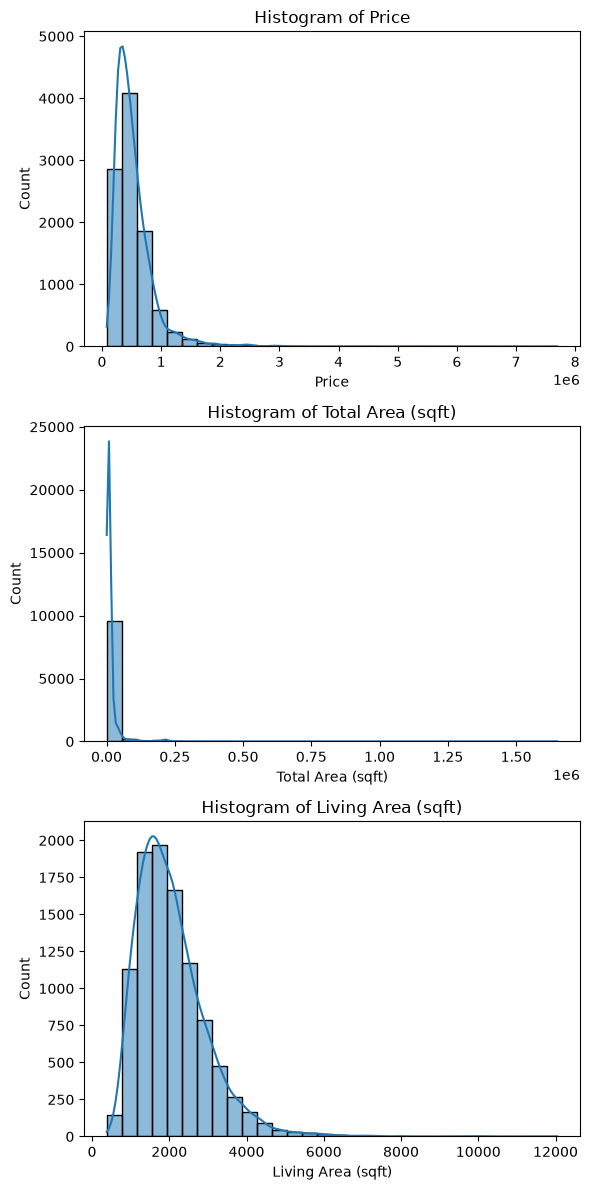

In [59]:
fig, axes = plt.subplots(len(variables), 1, figsize=(6, 4 * len(variables)))

for i, variable in enumerate(variables):
  sns.histplot(df[variable], bins=30, kde=True, ax=axes[i])
  axes[i].set_title(f'Histogram of {variable}')

plt.tight_layout()
plt.show()

**Interpretation of Visualizations**

**1. Price:** right-skewed

**2. Total Area:** it has an extremely severe skew even more than price

**3. Living Area:** it leans right but more normal looking than the other variables

From the interpretation above, it is evident that the method that will be employed for detecting outliers is the IQR method. The Histograms above do not have a symmetric bell curve; they are all leaning right.

##### Detecting Outliers using 1.5IQR
In this step, outlier detection of the ccolumns in question will be handled using the 1.5IQR rule.

In [60]:
def iqr_outliers(series: pd.Series):
  """
    Calculates outliers for a given variable
    param series: the variable for which the outlier is to be calculated
  """
  q1 = series.quantile(0.25)
  q3 = series.quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - (1.5 * iqr)
  upper_bound = q3 + (1.5 * iqr)
  outliers = series[(series < lower_bound) | (series > upper_bound)]
  return q1, q3, iqr, lower_bound, upper_bound, outliers

for variable in variables:
  q1, q3, iqr, lower_bound, upper_bound, outliers = iqr_outliers(df[variable])
  print(f'----- {variable} -----')
  print(f'Q1: {round(q1, 2)}, Q3: {round(q3, 2)}, IQR: {round(iqr, 2)}')
  print(f'Lower Bound: {round(lower_bound, 2)}, Upper Bound: {round(upper_bound, 2)}')
  print(f'Number of Outliers: {len(outliers)} Percentage of Outliers: {len(outliers)/len(df) * 100:.2f}%')
  print()

----- Price -----
Q1: 315000.0, Q3: 640000.0, IQR: 325000.0
Lower Bound: -172500.0, Upper Bound: 1127500.0
Number of Outliers: 496 Percentage of Outliers: 4.99%

----- Total Area (sqft) -----
Q1: 5428.0, Q3: 11183.25, IQR: 5755.25
Lower Bound: -3204.88, Upper Bound: 19816.12
Number of Outliers: 1185 Percentage of Outliers: 11.92%

----- Living Area (sqft) -----
Q1: 1410.0, Q3: 2500.0, IQR: 1090.0
Lower Bound: -225.0, Upper Bound: 4135.0
Number of Outliers: 278 Percentage of Outliers: 2.80%



As seen above for Price, Total Area, and Living Area, the Lower Fence is negative. This has no real-world meaning (a property cannot cost or measure less than zero), so effectively every flagged outlier for these three variables sits above the upper fence only.

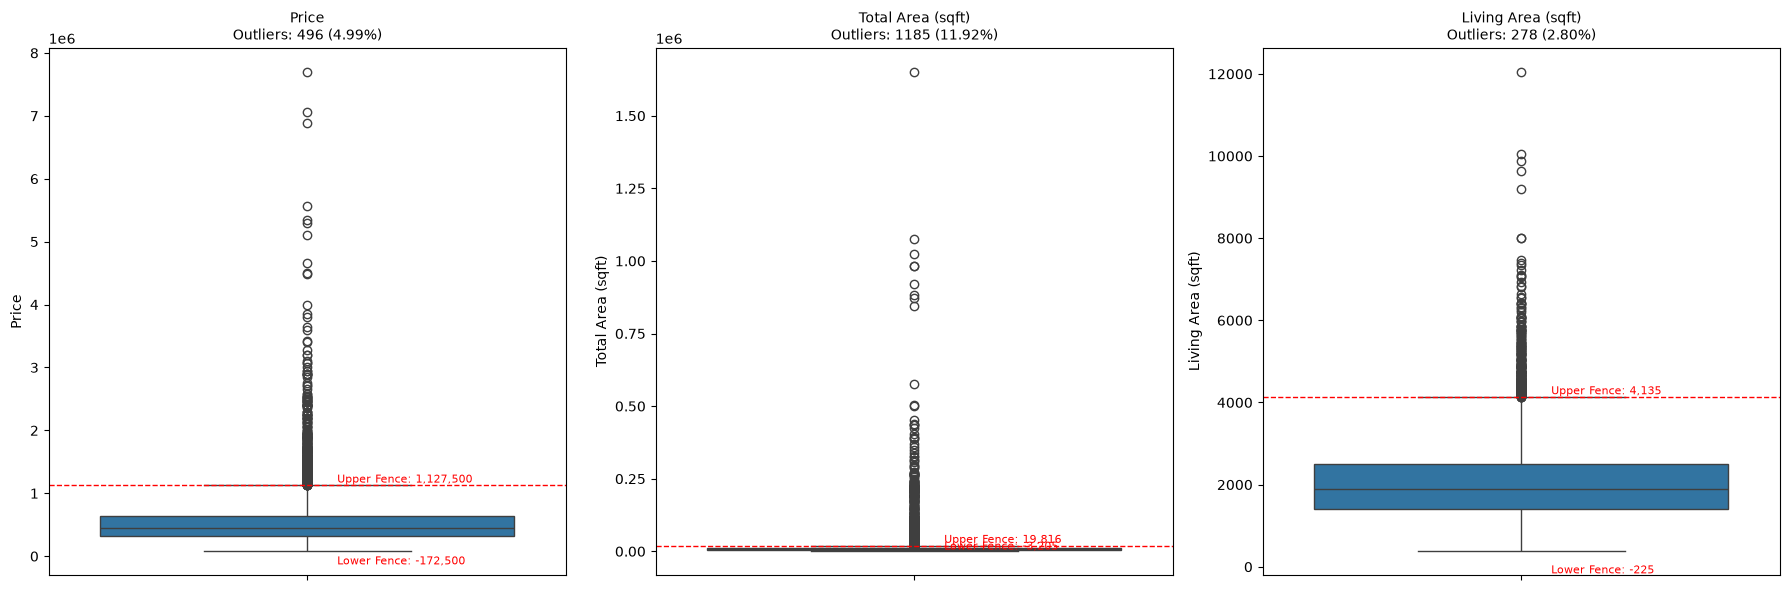

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, variable in enumerate(variables):
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    n_out = ((df[variable] < q1 - 1.5*iqr) | (df[variable] > upper)).sum()

    sns.boxplot(y=df[variable], ax=axes[i])
    axes[i].set_title(f'{variable}\nOutliers: {n_out} ({n_out/len(df)*100:.2f}%)', fontsize=10)
    axes[i].axhline(upper, color='red', linestyle='--', linewidth=1)
    axes[i].text(0.05, upper, f' Upper Fence: {upper:,.0f}', color='red', fontsize=8, va='bottom')
    axes[i].text(0.05, lower, f' Lower Fence: {lower:,.0f}', color='red', fontsize=8, va='bottom')

plt.tight_layout()
plt.show()

Now that the outliers have been detected, the next step is handling them. It is known that outlier detection is a statistical question while outlier treatment is a domain-knowledge decision. The result showed what values are statistically high and in order to handle them, the question "why?" (why are they unusually high) must be answered for each variable to determine the correct action for handling them. The decision framework is as follows:

| Question | If yes | If no |
| -------- | ------ | ----- |
| Is there a specific, identifiable reason the value is impossible or wrong (measurement/entry error)? | Correct or remove | Continue below |
| Is the value plausible given real-world context, even if extreme? | Retain (removing it would bias the dataset towards "typical" cases only) | Investigate individual rows further (consider flagging) |

**Applying the framework to each variable**

In [62]:
# Variable 1: Price
print('Rows containing outliers for the price column:')
price_outlier_rows = df.query('Price > 1127500')
display(price_outlier_rows.head(20).sort_values(by='Property Grade', ascending=True))

Rows containing outliers for the price column:


,Price,Number of Bedrooms,Number of Bathrooms,Living Area (sqft),Total Area (sqft),Number of Floors,Property Condition,Property Grade,Year Built,Year Renovated
427,1300000,3,2.00,2350,15021,1.0,4,8,1976,0
69,1325000,5,2.25,3200,20158,1.0,3,8,1965,0
125,1450000,4,2.75,2750,17789,1.5,3,8,1914,1992
21,2000000,3,2.75,3050,44867,1.0,3,9,1968,0
472,1199000,4,2.75,4110,8400,2.0,3,9,1928,2013
246,2400000,4,2.50,3650,8354,1.0,3,9,2000,0
282,2050000,5,3.00,3830,8480,2.0,5,9,1905,1994
49,1350000,3,2.50,2753,65005,1.0,5,9,1953,0
216,1505000,5,3.00,3300,33474,1.0,3,9,1957,1991
300,3075000,4,5.00,4550,18641,1.0,3,10,2002,0


*Value is plausible given real-world context*

From the correlation heatmap above, it is seen that Property Grade and Price have a strong correlation as well as Living Area and Price. The result in the previous cell shows that the houses with extreme prices represent a luxury housing segment and Berlin is genuinely known for this. It also seen that these houses with extreme prices have high Property Grade (with a minimum value of 8) with other factors such as Living Area (with Number of Bedrooms and Bathrooms)

One of the objectives of this project as stated in the brief is to be able to predict possible housing market trends in the future and removing 5% (Price outlier percentage rounded) of housing data would work against this purpose as the dataset would then contain only "typical" housing data without considering luxurious cases. Therefore, the outliers in the Price column would be retained.

In [63]:
# variable 2: Living Area (sqft)
print('Rows containing outliers for the Living Area column:')
living_area_outlier_rows = df.query('`Living Area (sqft)` > 4135').sort_values('Living Area (sqft)', ascending=False)
display(living_area_outlier_rows.head(20))

Rows containing outliers for the Living Area column:


,Price,Number of Bedrooms,Number of Bathrooms,Living Area (sqft),Total Area (sqft),Number of Floors,Property Condition,Property Grade,Year Built,Year Renovated
7252,7700000,6,8.00,12050,27600,2.5,4,13,1910,1987
3914,7062500,5,4.50,10040,37325,2.0,3,11,1940,2001
9254,6885000,6,7.75,9890,31374,2.0,3,13,2001,0
8092,4668000,5,6.75,9640,13068,1.0,3,12,1983,2009
4411,5570000,5,5.75,9200,35069,2.0,3,13,2001,0
1164,5110800,5,5.25,8010,45517,2.0,3,12,1999,0
1448,5350000,5,5.00,8000,23985,2.0,3,12,2009,0
4024,800000,7,6.75,7480,41664,2.0,3,11,1953,0
1315,5300000,6,6.00,7390,24829,2.0,4,12,1991,0
2713,1110000,5,3.50,7350,12231,2.0,3,11,2001,0


The % of outliers for the Living Area column (2.80%) is the smallest compared to the other columns. Additionally, there is no evidence pointing to errors in the values. Looking at the dataframe above highlighting the rows containing outliers, comparing the Living Area column with the Price, Number of Bedrooms, and Number of Bathrooms specifically, it is seen that the extreme values in this column are consistent with genuinely large properties. Therefore, the outliers in this column will be maintained.

In [64]:
# Variable 3: Total Area (sqft)
print('Rows containing outliers for the Total Area column:')
total_area_outlier_rows = df.query('`Total Area (sqft)` > 19816.12').sort_values('Total Area (sqft)', ascending=False)
display(total_area_outlier_rows.head(20))

Rows containing outliers for the Total Area column:


,Price,Number of Bedrooms,Number of Bathrooms,Living Area (sqft),Total Area (sqft),Number of Floors,Property Condition,Property Grade,Year Built,Year Renovated
1719,700000,4,1.00,1300,1651359,1.0,4,6,1920,0
7647,542500,5,3.25,3010,1074218,1.5,5,8,1931,0
7769,855000,4,3.50,4030,1024068,2.0,3,10,2006,0
3949,998000,4,3.25,3770,982998,2.0,3,10,1992,0
4441,790000,2,3.00,2560,982278,1.0,3,8,2004,0
6691,1998000,2,2.50,3900,920423,2.0,3,12,2009,0
7077,1650000,4,3.25,3920,881654,3.0,3,11,2002,0
9714,937500,4,4.00,5545,871200,2.0,3,11,2003,0
4540,550000,3,2.00,3650,843309,2.0,4,7,1991,0
7294,700000,2,1.75,1679,577605,2.0,3,9,2001,0


Because Total Area and Price show weak correlation (0.1), using "large Total Area + large Price" as a consistency check is methodologically inconsistent. Instead, the most extreme rows will be converted to the appropriate metric unit used for measuring properties in Germany (meters squared [m2]) and checked against current Berlin property listings also taking into consideration the time frame (1900 - 2015) of when the houses were built.

In [65]:
# measurement unit conversion
SQFT_TO_M2 = 0.092903
df['Total Area (m2)'] = df['Total Area (sqft)'] * SQFT_TO_M2
total_area_outlier_rows = df.query('`Total Area (sqft)` > 19816.12').sort_values(['Total Area (sqft)', 'Year Built'], ascending=False)
display(total_area_outlier_rows.head(10))

,Price,Number of Bedrooms,Number of Bathrooms,Living Area (sqft),Total Area (sqft),Number of Floors,Property Condition,Property Grade,Year Built,Year Renovated,Total Area (m2)
1719,700000,4,1.00,1300,1651359,1.0,4,6,1920,0,153416.205177
7647,542500,5,3.25,3010,1074218,1.5,5,8,1931,0,99798.074854
7769,855000,4,3.50,4030,1024068,2.0,3,10,2006,0,95138.989404
3949,998000,4,3.25,3770,982998,2.0,3,10,1992,0,91323.463194
4441,790000,2,3.00,2560,982278,1.0,3,8,2004,0,91256.573034
6691,1998000,2,2.50,3900,920423,2.0,3,12,2009,0,85510.057969
7077,1650000,4,3.25,3920,881654,3.0,3,11,2002,0,81908.301562
9714,937500,4,4.00,5545,871200,2.0,3,11,2003,0,80937.093600
4540,550000,3,2.00,3650,843309,2.0,4,7,1991,0,78345.936027
7294,700000,2,1.75,1679,577605,2.0,3,9,2001,0,53661.237315


The upper-bound outliers ranging from 19816.12sqft(1840.98m2) up to 1651359sqft(153416.21m2) may reflect valid, historically accurate pdata for multi-family residential blocks, social housing complexes, post-war mega-estates, or privatized portfolio estates rather than errors. Therefore, the outliers in this column will be retained as well.

As data analysis comes up next, the Living Area and Total Area columns would be handled to have a real-world reflection. The following will be done:
- Living Area will be converted to m2 to reflect German measuring standards and the existing column in sqft will be dropped.
- Total Area column in sqft will be dropped as well.

Lastly, a new column will be created to facilitate analysis. A column of type boolean representing whether or not a house was renovated will be created from the `Year Renovated` column.



In [66]:
df['Living Area (m2)'] = df['Living Area (sqft)'] * SQFT_TO_M2
df.drop(['Living Area (sqft)', 'Total Area (sqft)'], axis=1, inplace=True)
df['Renovation Status'] = df['Year Renovated'] > 0
df.columns

Index(['Price', 'Number of Bedrooms', 'Number of Bathrooms',
       'Number of Floors', 'Property Condition', 'Property Grade',
       'Year Built', 'Year Renovated', 'Total Area (m2)', 'Living Area (m2)',
       'Renovation Status'],
      dtype='str')

## Stage 4: Dataset Validation
Now that preprocessing is complete, a second exploration of the dataset would be done in order to show the before (as seen above in previous cells) and after state of the dataset.

In [67]:
print(f'1. Dataset shape: {df.shape}')
print(f'2. Missing values count: {df.isnull().sum().sum()}')
print(f'3. Duplicate row counts: {df.duplicated().sum()}')
print(f'4. Verifying data types: \n\n{df.dtypes}\n')
print(f'5. New descriptive statistics: \n\n')
display(df.describe())

1. Dataset shape: (9940, 11)
2. Missing values count: 0
3. Duplicate row counts: 0
4. Verifying data types: 

Price                    int64
Number of Bedrooms       int64
Number of Bathrooms    float64
Number of Floors       float64
Property Condition       int64
Property Grade           int64
Year Built               int64
Year Renovated           int64
Total Area (m2)        float64
Living Area (m2)       float64
Renovation Status         bool
dtype: object

5. New descriptive statistics: 




,Price,Number of Bedrooms,Number of Bathrooms,Number of Floors,Property Condition,Property Grade,Year Built,Year Renovated,Total Area (m2),Living Area (m2)
count,9.940000e+03,9940.000000,9940.000000,9940.000000,9940.000000,9940.000000,9940.000000,9940.000000,9940.000000,9940.000000
mean,5.337212e+05,3.365392,2.063959,1.431137,3.447887,7.594970,1967.245775,91.383300,1491.359372,190.854334
std,3.772516e+05,0.910686,0.765467,0.510786,0.667019,1.162921,27.985419,417.268804,4194.297472,84.651228
min,8.000000e+04,1.000000,0.500000,1.000000,1.000000,3.000000,1900.000000,0.000000,53.140516,35.303140
25%,3.150000e+05,3.000000,1.500000,1.000000,3.000000,7.000000,1950.000000,0.000000,504.277484,130.993230
50%,4.464750e+05,3.000000,2.000000,1.000000,3.000000,7.000000,1969.000000,0.000000,735.327245,175.586670
75%,6.400000e+05,4.000000,2.500000,2.000000,4.000000,8.000000,1990.000000,0.000000,1038.957475,232.257500
max,7.700000e+06,11.000000,8.000000,3.000000,5.000000,13.000000,2015.000000,2015.000000,153416.205177,1119.481150


### Stage 5: Data Analysis & Visualization

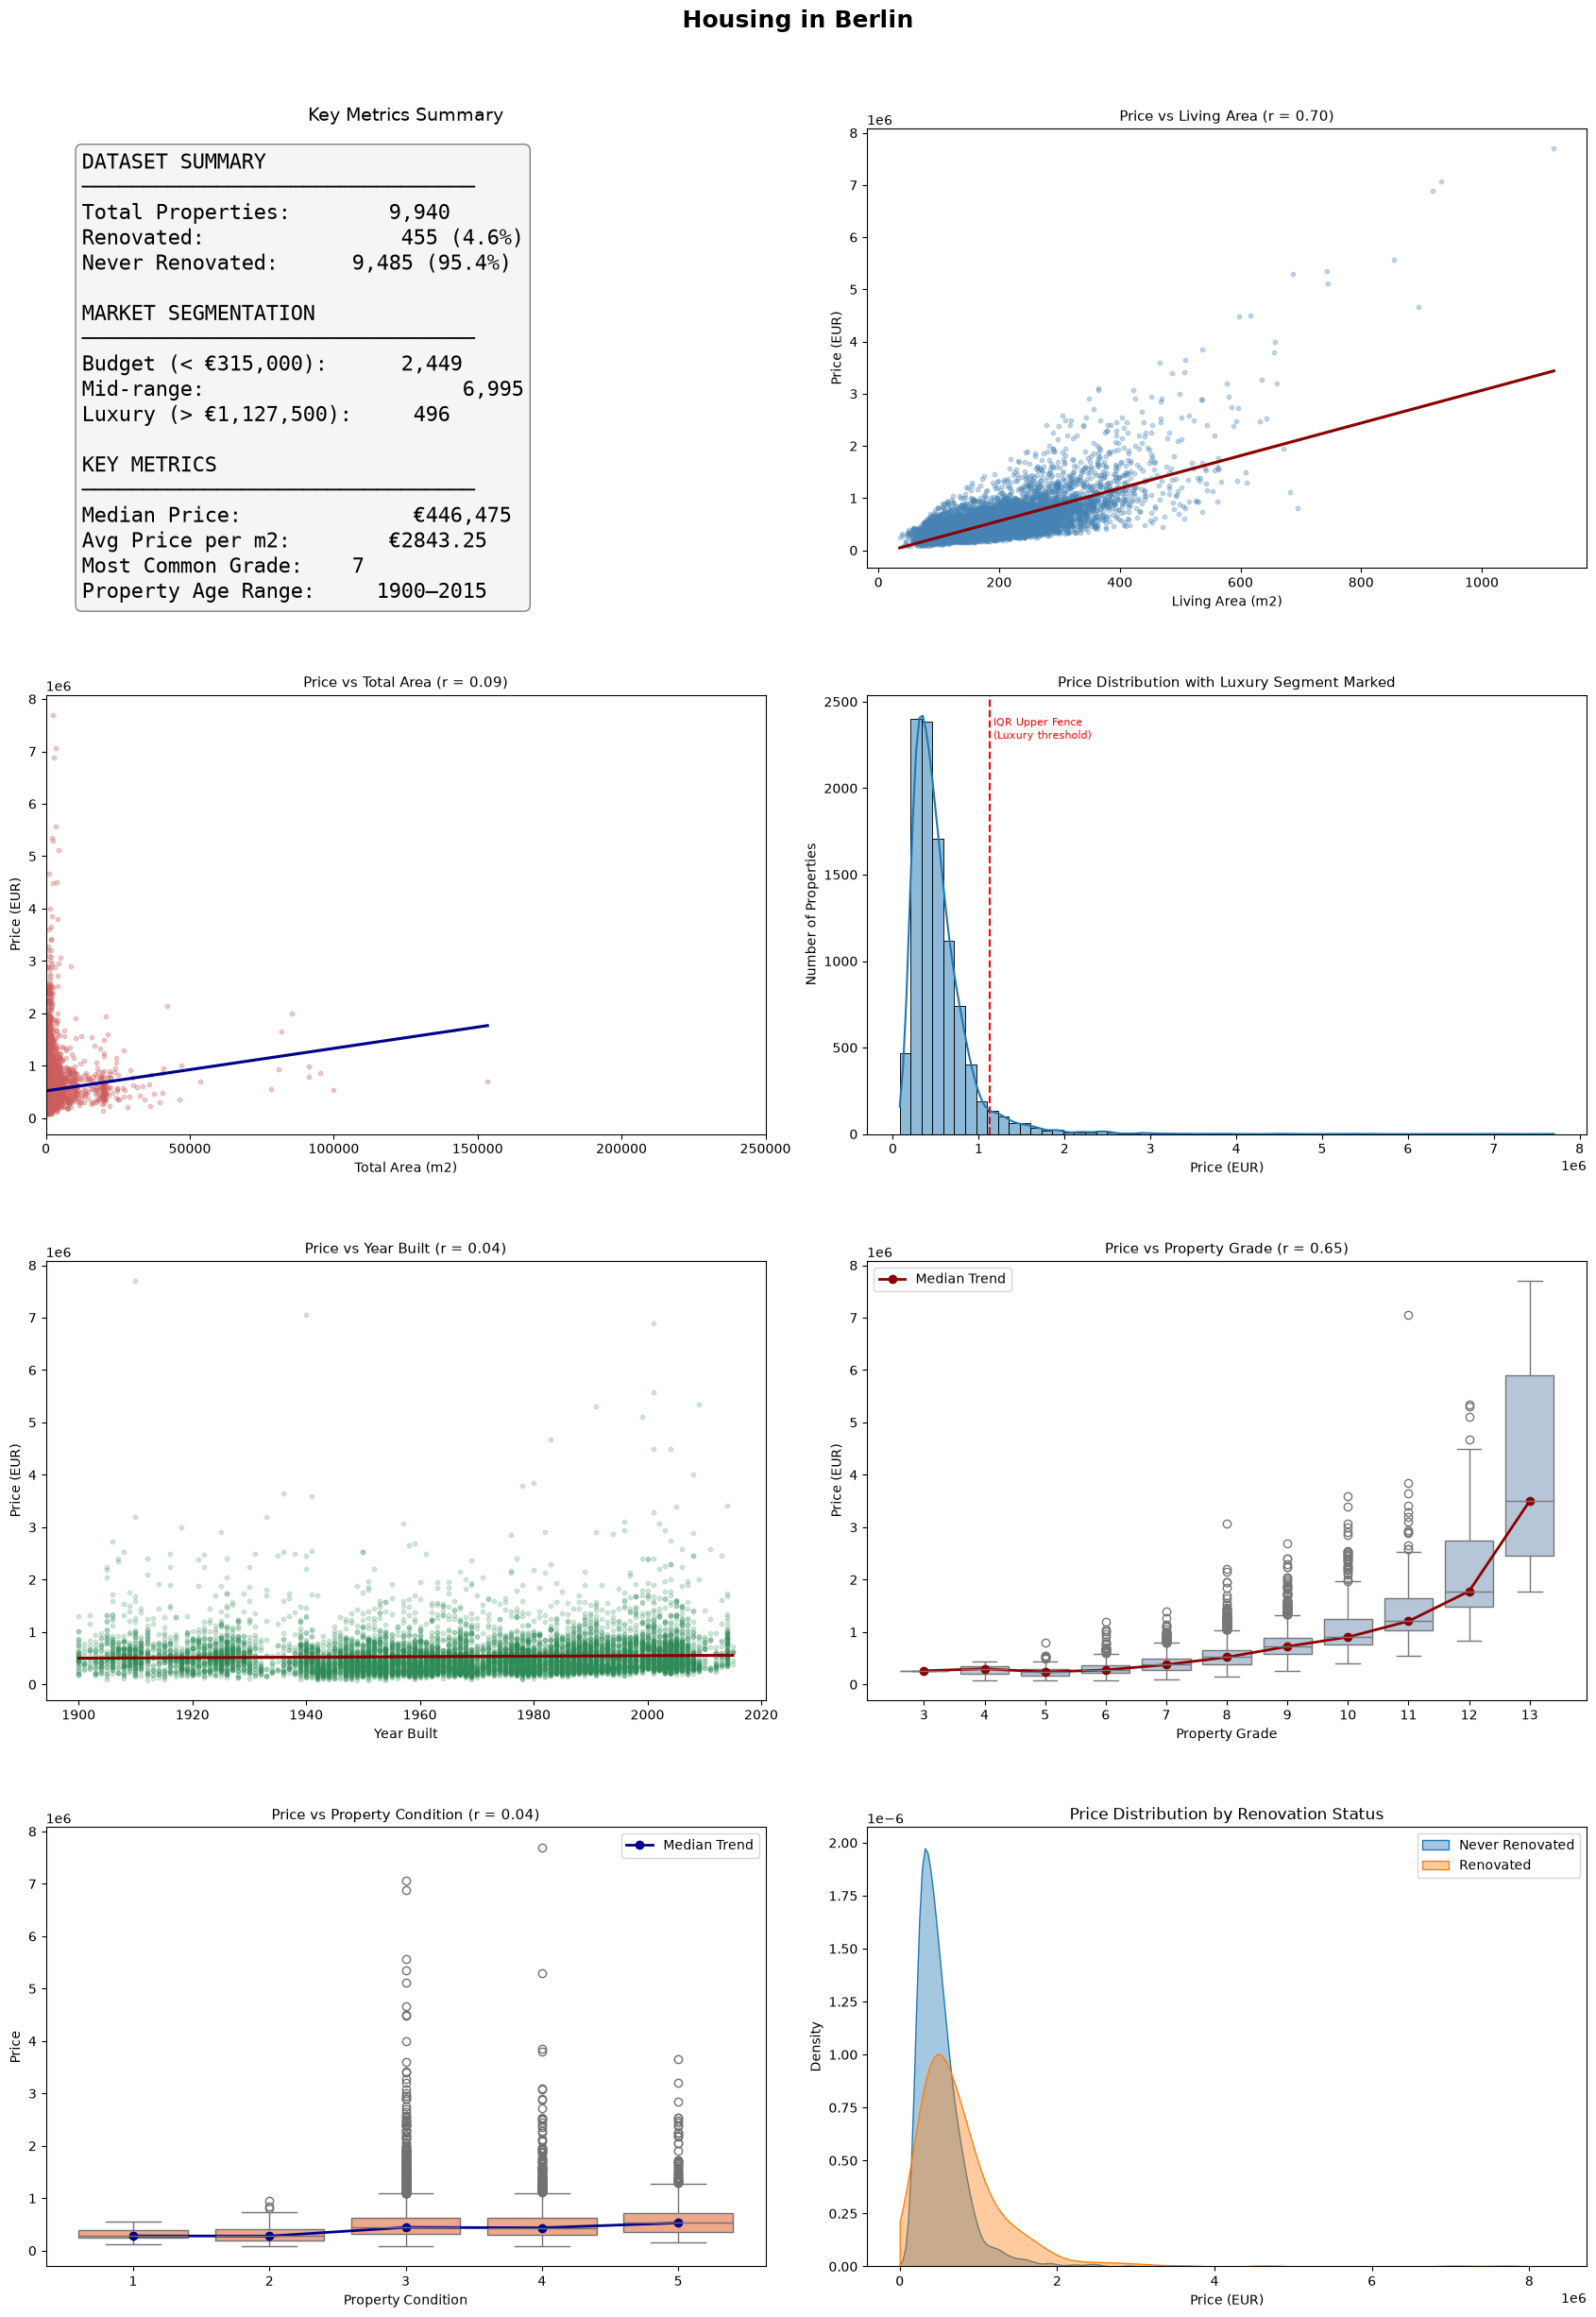

In [68]:
fig, axes = plt.subplots(4, 2, figsize=(17, 24))
fig.suptitle('Housing in Berlin', fontsize=18, fontweight='bold', ha='center', y=1.02)

# 1. KPI Summary Panel
axes[0,0].axis('off')
kpi_text = (
    f"DATASET SUMMARY\n"
    f"{'─'*32}\n"
    f"Total Properties:        {len(df):,}\n"
    f"Renovated:                {df['Renovation Status'].sum():,} ({df['Renovation Status'].mean()*100:.1f}%)\n"
    f"Never Renovated:      {(~df['Renovation Status']).sum():,} ({(~df['Renovation Status']).mean()*100:.1f}%)\n\n"
    f"MARKET SEGMENTATION\n"
    f"{'─'*32}\n"
    f"Budget (< €315,000):      {(df['Price']<315000).sum():,}\n"
    f"Mid-range:                     {((df['Price']>=315000)&(df['Price']<=1127500)).sum():,}\n"
    f"Luxury (> €1,127,500):     {(df['Price']>1127500).sum():,}\n\n"
    f"KEY METRICS\n"
    f"{'─'*32}\n"
    f"Median Price:              €{df['Price'].median():,.0f}\n"
    f"Avg Price per m2:        €{(df['Price']/df['Living Area (m2)']).mean():.2f}\n"
    f"Most Common Grade:    {df['Property Grade'].mode()[0]}\n"
    f"Property Age Range:     {int(df['Year Built'].min())}–{int(df['Year Built'].max())}"
)
axes[0,0].text(0.05, 0.95, kpi_text, fontsize=16, va='top', ha='left',
               fontfamily='monospace', transform=axes[0,0].transAxes,
               bbox=dict(boxstyle='round', facecolor='whitesmoke', edgecolor='gray'))
axes[0,0].set_title('Key Metrics Summary', fontsize=14)

# 2. Price vs Living Area
sns.regplot(x='Living Area (m2)', y='Price', data=df, ax=axes[0,1],
            scatter_kws={'alpha':0.3,'s':10,'color':'steelblue'}, line_kws={'color':'darkred'}, ci=None)
axes[0,1].set_title('Price vs Living Area (r = 0.70)', fontsize=11)
axes[0,1].set_xlabel('Living Area (m2)'); axes[0,1].set_ylabel('Price (EUR)')

# 3. Price vs Total Area
sns.regplot(x='Total Area (m2)', y='Price', data=df, ax=axes[1,0],
            scatter_kws={'alpha':0.3,'s':10,'color':'indianred'}, line_kws={'color':'darkblue'}, ci=None)
axes[1,0].set_title('Price vs Total Area (r = 0.09)', fontsize=11)
axes[1,0].set_xlabel('Total Area (m2)'); axes[1,0].set_ylabel('Price (EUR)')
axes[1,0].set_xlim(0, 250000)

# 4. Price distribution with luxury segment marked
sns.histplot(df['Price'], bins=60, kde=True, ax=axes[1,1])
upper_fence = 1127500
axes[1,1].axvline(upper_fence, color='red', linestyle='--')
axes[1,1].text(upper_fence, axes[1,1].get_ylim()[1]*0.9, ' IQR Upper Fence\n (Luxury threshold)', color='red', fontsize=8)
axes[1,1].set_title('Price Distribution with Luxury Segment Marked', fontsize=11)
axes[1,1].set_xlabel('Price (EUR)'); axes[1,1].set_ylabel('Number of Properties')

# 5. Price vs Year Built
sns.regplot(x='Year Built', y='Price', data=df, ax=axes[2,0],
            scatter_kws={'alpha':0.2,'s':10,'color':'seagreen'}, line_kws={'color':'darkred'}, ci=None)
axes[2,0].set_title('Price vs Year Built (r = 0.04)', fontsize=11)
axes[2,0].set_xlabel('Year Built'); axes[2,0].set_ylabel('Price (EUR)')

# 6. Price vs Property Grade (boxplot + median trend line)
sns.boxplot(x='Property Grade', y='Price', data=df, ax=axes[2,1], color='lightsteelblue')
grade_medians = df.groupby('Property Grade')['Price'].median()
axes[2,1].plot(range(len(grade_medians)), grade_medians.values, color='darkred', marker='o', linewidth=2, label='Median Trend')
axes[2,1].set_title('Price vs Property Grade (r = 0.65)', fontsize=11)
axes[2,1].set_xlabel('Property Grade'); axes[2,1].set_ylabel('Price (EUR)')
axes[2,1].legend()

# 7. Price vs Property Condition (boxplot + median trend line)
sns.boxplot(x='Property Condition', y='Price', data=df, ax=axes[3,0], color='lightsalmon')
cond_medians = df.groupby('Property Condition')['Price'].median()
axes[3,0].plot(range(len(cond_medians)), cond_medians.values, color='darkblue', marker='o', linewidth=2, label='Median Trend')
axes[3,0].set_title('Price vs Property Condition (r = 0.04)', fontsize=11)
axes[3,0].set_xlabel('Property Condition'); axes[2,1].set_ylabel('Price (EUR)')
axes[3,0].legend()

# 8. Price vs Renovation Status
sns.kdeplot(df[df['Renovation Status']==False]['Price'], label='Never Renovated', clip=(0, None), fill=True, alpha=0.4, ax=axes[3,1])
sns.kdeplot(df[df['Renovation Status']==True]['Price'], label='Renovated', clip=(0, None), fill=True, alpha=0.4, ax=axes[3,1])
axes[3,1].set_title('Price Distribution by Renovation Status')
axes[3,1].set_xlabel('Price (EUR)'); axes[3,1].legend()

plt.tight_layout()
plt.show()

## Stage 6: Findings, Interpretations, Recommendations, and Limitations
This section is dedicated for reporting based on the analysis conducted in Stage 5

### Part 1: Interpretation of Visuals and Justification for Method of Choice

**1. Correlation Analysis and Outlier Detection:**

_Note: All findings here have been explained above_

Right from the beginning when attempting to understand correlation and detect outliers, a **heatmap**, **histograms**, and **boxplots** were used. Unlike the result of the Pearson correlation matrix (in tabular form), a heatmap allows for that result to scanned via color intensity rather than requiring the reader to parse a table of numbers one cell at at time.

The histograms with the Kernel Density Estimate (KDE) line displayed the distribution of data which enabled determining the method to use for outlier detection. After deciding on the outlier detection method (1.5 IQR), boxplots were used to give a visual representation of the outliers. It is worth noting that boxplots use the same quartile logic as the IQR calculation itself making it the best visual choice as the visual and statistical method are directly consistent with one another.

**2. Visuals from Analysis:**

- *Scatterpots with trendlines (Price vs Living Area | Price vs Total Area | Price vs Year Built):* scatterplots are the correct visuals for 2 continuous variables and the linear trendline gives the Pearson correlation coeficient a visible anchor. It serves explicitly as a descriptive visual aid and not a prediction.
  - `Price vs Living Area`: It shows a clear upward-sloping cloud with widening spread at higher values. This means properties with larger living areas tend toward higher prices.
  - `Price vs Total Area`: It shows a flat, shapeless scatter, visually confirming its near-zero correlation. This means Total Area does not have much of an effect on pricing.
  - `Price vs Year Built`: It shows a flat, directionless pattern implying that construction year alone does not meaningfully predict price in this dataset.

- *Price Histogram with Luxury Threshold*: This was displayed once again to give a visual representation of the count of houses that fall into various pricing category. It is seen that majority of the houses in this dataset are "affordable" with less than 500 of them being luxurious.

- *Boxplots with Trendlines (Price vs Property Grade | Price vs Property Condition)*: The boxplot here was chosen because it summarizes the price distributuon within each category rating of property grade and property condition. For the trendline, the median was used because it is the only one of the three (mean, mode, median) that gices one trustworthy typical number per group every time. Mean gets distorted by expensive outliers and mode often does not exist for a variable like Price where values rarely repeat.
  - `Price vs Property Grade`: Property Grade shows a near-monotonic staircase where priceing rose consistently confirming its strong correlation value.
  - `Price vs Property Condtiion`: It shows no consistent pattern which is in line with its negligible correlation.

- *KDE (Kernel Density Estimate) overlay plot of Price vs Renovation Status:* This visual was used because it directly compares where the groups' price distributions diverge along the same axis. Both curves peak at the lower range but the "Never Renovated" curve peaks higher and sharper compared to "Renovated" which curve's peak is shorter and shifted to the right. This shows that never renovated properties tend to be cheaper on average and renovated ones tend to be pricier.

- The key metrics summary was included because without going into every statistical detail, a concise, skimmable summary helps support quick decision making.

### Part 2: Key Findings and Recommendations
For the data analyst manager

1. Living Area (r=0.70) and Property Grade (r=0.65) are the dominant price drivers. **These 2 variables should be prioritized as the core inputs for any future pricing or valuation work** as they are the most reliable, evidence-backed price indicators in this dataset. Moreover, tracking the grade composition of new construction or major renovations entering the market could serve as an early indicator of upward price pressure. Additionally, it is worth noting that properties that are large (living area), highly graded, and renovated each individually show a strong association with higher price, suggesting their combination is likely to correspond with premium pricing, though this was not tested as a combined effect.

2. Total Area (r=0.09), Property Condition (r=0.04), and Year Built (r=0.04) are weak and unreliable price predictors. **Do not rely on these variables in isolation for price estimation**; their inclusion in a pricing model would likely add noise and if included should be investigated further only in combination with other values.

3. The Berlin housing market as per this dataset has a distinct genuine luxury segment. Approximately 5% of properties sit aboce the IQR-derived luxury threshold which forms a visibly seprate tail in the price distribution. **Any future trend analysis and reporting should segment "typical" and "luxury" properties separately.** A single blended average price would misrepresent both groups and could mislead trend forecasting.

4. Renovation is associated with a meaningful price premium, but the evidence base is limited. **Treat this as a promising but preliminary signal. Before using renovation status as a confident pricing factor, a larger sample of renovated properties (or a follow-up data collection effort) would strengthen the finding's reliability.**

5. The columns `Living Area (sqft)` and `Living Area (sqft) 2` are related (r=0.75) but distinct and `Living Area (sqft) 2` diverges more for renovated properties. Retain Living Area as the standard working variable in the interim because of its stronger price correlation and direct relevance to the brief.; **Living Area 2's exact meaning should be clarified with the data source before further use.**

6. The Total Area column values contained many extreme values (1185) and could not be conclusively confirmed as errors or real-world data. The most extreme of these values ranged from 50,000m2 upward and could not be matched against single family listings in Berlin, but may plausibly reflect multi-family blocks, social housing, or portfolio estates rather than errors and they were therefore retained. However, **a `Property Type` field at data collection should be added to allow such values to be validated against the correct category,** rather than a single threshold applied uniformly.

### Part 3: Limitations

- **Correlation, not causation:** all relationships reported (Living Area, Grade, Renovation vs. Price) are statistical associations, not proven causal effects.

- The dataset is a single snapshot in time (Year Built/Renovated only); it cannot directly show how prices are changing over time, limiting true trend forecasting.

- Property Condition 1–2 (12 and 84 properties) and the renovated group (4.6% of the dataset) are comparatively small, reducing confidence in findings tied to them.

- Unresolved Total Area ambiguity: the extreme values could not be conclusively confirmed as errors or genuine properties as real-world checks relied mainly on publicly available listings only, which may not always capture social housing, portfolio, or institutionally-held estates.

- **No predictive model applied:** per the brief, findings are descriptive only meaning no model was built to formally quantify combined effects (e.g. Living Area + Property Grade + Renovation Status together).

- Findings are specific to this dataset and may not generalize to Berlin's housing market as a whole without further validation against a larger or more recent sample.



In [69]:
print(f'Renovated houses % {(len(df.query('`Renovation Status` == True')) / len(df)) * 100}')
print(f'Count of Property Condition 1: {len(df.query('`Property Condition` == 1'))}')
print(f'Count of Property Condition 2: {len(df.query('`Property Condition` == 2'))}')

Renovated houses % 4.577464788732395
Count of Property Condition 1: 12
Count of Property Condition 2: 84
